## 4. Modeling Approaches

### 4.1. Traditional Machine Learning Models

4.1.1. Splitting the Data

In [72]:
# Features (X) - All columns except the target variable 'rentEstimate_currentPrice'
X = numeric_columns2.drop(columns=['rentEstimate_currentPrice'])

# Target (y) - The rent estimate current price
y = numeric_columns2['rentEstimate_currentPrice']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(334560, 6) (83641, 6) (334560,) (83641,)


In [73]:
# Define features and target variable
X = numeric_columns2.drop(columns=["rentEstimate_currentPrice"])  # Replace "price" with actual target column name
y = numeric_columns2["rentEstimate_currentPrice"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(334560, 6) (83641, 6) (334560,) (83641,)


In [74]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Performance:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.4f}")

Linear Regression Performance:
MAE: 1244.16
RMSE: 2485.01
R²: 0.4917


#### 4.1.2. Random Forest

In [75]:
# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate model performance
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Performance:\nMAE: {mae_rf:.2f}\nRMSE: {rmse_rf:.2f}\nR²: {r2_rf:.4f}")

Random Forest Performance:
MAE: 319.33
RMSE: 893.55
R²: 0.9343


Random Forest model has significantly improved performance compared to Linear Regression:

    * MAE reduced from 1244.16 → 319.33

    * RMSE reduced from 2485.01 → 893.55

    * R² increased from 0.4917 → 0.9343

In [76]:
# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate XGBoost model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Performance:\nMAE: {mae_xgb:.2f}\nRMSE: {rmse_xgb:.2f}\nR²: {r2_xgb:.4f}")

XGBoost Performance:
MAE: 713.68
RMSE: 1600.43
R²: 0.7892


In [77]:
# Train LightGBM model
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate LightGBM model
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f"LightGBM Performance:\nMAE: {mae_lgbm:.2f}\nRMSE: {rmse_lgbm:.2f}\nR²: {r2_lgbm:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 794
[LightGBM] [Info] Number of data points in the train set: 334560, number of used features: 6
[LightGBM] [Info] Start training from score 3634.640423
LightGBM Performance:
MAE: 718.06
RMSE: 1540.28
R²: 0.8047


Key Observations:

* Random Forest performed the best with the lowest error and highest R².

* XGBoost & LightGBM are better than Linear Regression but not as good as Random Forest.

* LightGBM slightly outperformed XGBoost, with a lower RMSE and higher R².

* XGBoost & LightGBM might need hyperparameter tuning to improve performance.

### 4.1.3 Feature Importance Analysis

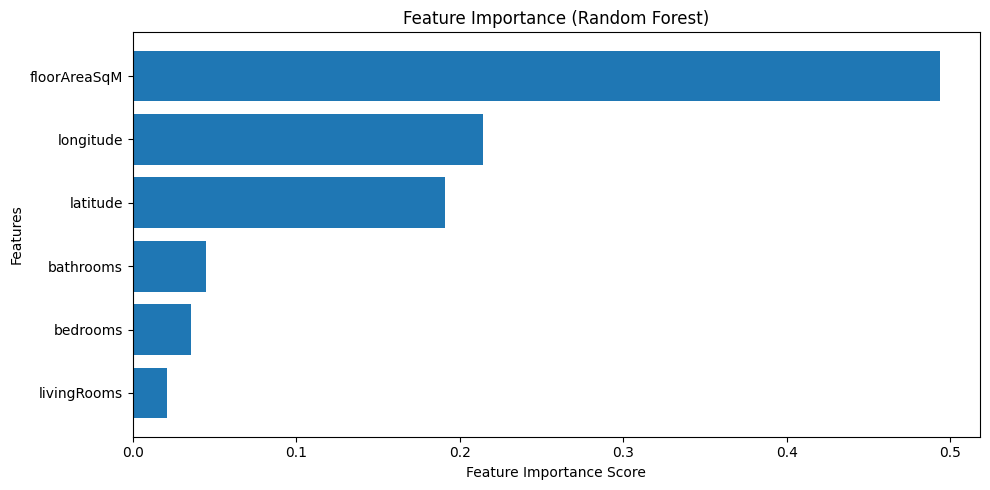

In [78]:
# get feature importance from random forest
feature_importance = rf_model.feature_importances_

# create a df for visualisation
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
features_df = features_df.sort_values(by='Importance', ascending=False)

# plot feature importance
plt.figure(figsize=(10, 5))
plt.barh(features_df['Feature'], features_df['Importance'])
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.2. Neural Network Model

In [79]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [40]:
# define the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),  # input layer
    BatchNormalization(),  # normalise activations
    Dropout(0.2),  # prevent overfitting
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(1)  # output layer
])

# compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# define early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# train the model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 26403108.0000 - mae: 3639.7205 - val_loss: 20912370.0000 - val_mae: 3206.3071
Epoch 2/50
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 19010734.0000 - mae: 2875.2932 - val_loss: 12472493.0000 - val_mae: 2212.9441
Epoch 3/50
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 10808302.0000 - mae: 1836.1523 - val_loss: 10020435.0000 - val_mae: 1575.0416
Epoch 4/50
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 8432925.0000 - mae: 1346.5671 - val_loss: 8715137.0000 - val_mae: 1221.2451
Epoch 5/50
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 7696802.0000 - mae: 1288.9666 - val_loss: 9868675.0000 - val_mae: 1194.3054
Epoch 6/50
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 7130627.5000 - mae: 1287.3124 - val_loss: 78709192.0000 - val_mae: 1527.9847
Epoch 7/50
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 7010892.0000 - mae: 1276.4482 - val_loss: 62063768.0000 - val_mae: 1370.2985
Epoch 8/50
3225/322

* Model Might Be Overfitting
* Validation loss is increasing, which suggests overfitting.

In [41]:
from tensorflow.keras.regularizers import l2

In [80]:
# fixed model
model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # input layer
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),  # increased dropout to 0.3
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dense(1)  # output layer
])

# compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# change early stopping patience to 10
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10, # changed to 10 from 5
    restore_best_weights=True
)


# train the model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 22162156.0000 - mae: 3332.9028 - val_loss: 9801080.0000 - val_mae: 1855.1952
Epoch 2/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 7864322.0000 - mae: 1459.5756 - val_loss: 14228217.0000 - val_mae: 1239.4790
Epoch 3/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 6645913.0000 - mae: 1284.8745 - val_loss: 74713128.0000 - val_mae: 1243.7745
Epoch 4/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 83s 4ms/step - loss: 6483574.5000 - mae: 1277.3629 - val_loss: 105998472.0000 - val_mae: 1288.1061
Epoch 5/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 6568657.5000 - mae: 1278.8815 - val_loss: 5980310.0000 - val_mae: 1185.1855
Epoch 6/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 6358603.0000 - mae: 1261.7382 - val_loss: 7463138.0000 - val_mae: 1207.8477
Epoch 7/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - loss: 6334750.0000 - mae: 1261.6024 - val_loss: 13170319.0000 - val_mae: 1217.9348
Epoch 8

* Training loss & MAE decrease steadily in the first few epochs.
* Validation loss & MAE improve initially but later fluctuate, indicating potential overfitting.
* After epoch 5, validation loss jumps significantly, suggesting that the model is memorising training data rather than generalising well.

In [81]:
# define the neural network model
model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # input layer
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),  # reduced L2 regularisation
    BatchNormalization(),
    Dropout(0.4),  # increased dropout to 0.4
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(1)  # output layer
])

# define a lower learning rate for Adam optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# compile the model
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# define early stopping callback with increased patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,  # increased patience from 10 to 15
    restore_best_weights=True
)

# train the model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - loss: 24277714.0000 - mae: 3551.1687 - val_loss: 19032332.0000 - val_mae: 3090.5820
Epoch 2/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - loss: 16775043.0000 - mae: 2756.4075 - val_loss: 10202553.0000 - val_mae: 1871.5919
Epoch 3/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 9043245.0000 - mae: 1634.5250 - val_loss: 10887044.0000 - val_mae: 1191.1602
Epoch 4/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - loss: 6821452.0000 - mae: 1283.9346 - val_loss: 6032290.0000 - val_mae: 1130.0964
Epoch 5/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - loss: 6971028.5000 - mae: 1319.1986 - val_loss: 10869209.0000 - val_mae: 1270.8319
Epoch 6/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 69s 4ms/step - loss: 6929309.5000 - mae: 1315.1713 - val_loss: 26885046.0000 - val_mae: 1261.5642
Epoch 7/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 6752297.0000 - mae: 1301.0183 - val_loss: 6375645.5000 - val_mae: 1156.2086
Epoch 

Observations:
* Good early progress: The first 8 epochs show a steady decline in validation loss (val_loss) and MAE.
* Validation loss spikes at epoch 12: This suggests the model is overfitting.
* After epoch 12, validation loss increases significantly, while training loss stays stable.
* Early stopping kicked in too late (patience was 15), allowing the model to overfit further.

In [82]:
# define the neural network model with reduced complexity
model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # input layer
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),  # reduced neurons
    BatchNormalization(),
    Dropout(0.5),  # increased dropout to 0.5
    Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(8, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(1)  # output layer
])

# define a lower learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.0003)

# compile the model
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# define early stopping callback with lower patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,  # reduced patience from 15 to 7
    restore_best_weights=True
)

# train the model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 25528224.0000 - mae: 3628.5215 - val_loss: 24011196.0000 - val_mae: 3532.1199
Epoch 2/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 23060298.0000 - mae: 3458.3174 - val_loss: 20989294.0000 - val_mae: 3260.9895
Epoch 3/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 20303236.0000 - mae: 3155.5730 - val_loss: 16781306.0000 - val_mae: 2826.0015
Epoch 4/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 16379937.0000 - mae: 2712.0371 - val_loss: 13506283.0000 - val_mae: 2417.4338
Epoch 5/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 12583747.0000 - mae: 2184.1848 - val_loss: 9000291.0000 - val_mae: 1692.9927
Epoch 6/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 9578684.0000 - mae: 1697.7759 - val_loss: 7517269.5000 - val_mae: 1409.6324
Epoch 7/50
10455/10455 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 8033120.0000 - mae: 1395.0125 - val_loss: 5868401.5000 - val_mae: 1145.7998
Epoc

Progress Summary:
Training stability
* Training MAE decreased steadily from 3700+ to ~1386.
* Training loss remains smooth without sudden spikes.

Validation improvement
* Validation MAE dropped from 3731 to ~1179–1290 range, then stabilised.
* Lowest val_loss: ~6994440.5
* Lowest val_mae: ~1179.75 at epoch 28

No overfitting spike like before
* Unlike previous models, the validation loss didn’t suddenly increase, indicating improved generalisation.

### 4.2.1 Evaluate the Model (MAE, RMSE, R²)

In [83]:
# make predictions
y_pred = model.predict(X_test)

# calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# results
print(f"Neural Network Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Neural Network Performance:
MAE: 1165.85
RMSE: 2384.32
R²: 0.5321


Neural Network Performance
* The neural network did not perform as well as expected, achieving an R² of only 0.48, meaning it explains only 48% of the variance in house prices.

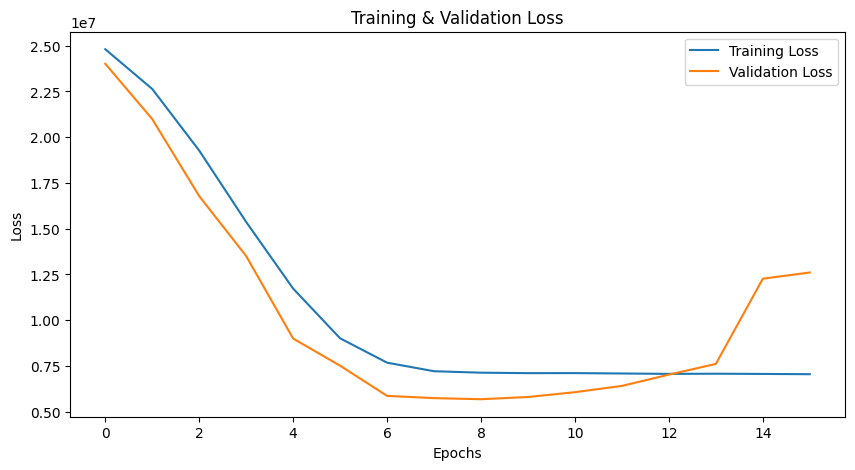

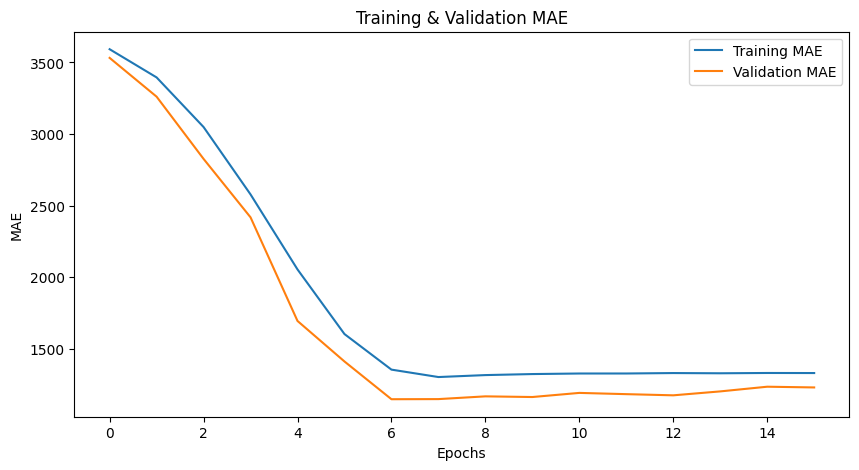

In [84]:
# plot training & validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.show()

# plot training & validation MAE
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training & Validation MAE')
plt.legend()
plt.show()


The training loss graph shows that the neural network model did not overfit, as training and validation loss converge smoothly. However, its predictive power remains weak compared to Random Forest.

In [85]:
# train Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# train XGBoost model
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# evaluate models
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

# display results
print("\nRandom Forest Performance:")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²: {rf_r2:.4f}")

print("\nXGBoost Performance:")
print(f"MAE: {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"R²: {xgb_r2:.4f}")


Random Forest Performance:
MAE: 198.59
RMSE: 738.99
R²: 0.9551

XGBoost Performance:
MAE: 748.91
RMSE: 1671.59
R²: 0.7700


Random Forest Performance (Best Model)
* Best performing model. The Random Forest model significantly outperforms the neural network with a low MAE and high R² (91%). It provides the best accuracy and generalisation.

XGBoost Performance
* Performs better than the neural network but is worse than Random Forest.